# Car Price Analysis

## Objectives

* Analyse car prices in the US market to identify the key factors that influence vehicle pricing. The analysis will examine relationships between vehicle characteristics, engine specifications, performance, fuel economy and price. The findings will help an automobile company entering the US market make informed decisions about vehicle design, pricing and business strategy.
## Business Context and Analytics Applications

The automotive industry can use data analytics to support a range of business decisions, including vehicle pricing, market segmentation, competitive analysis, demand forecasting and product positioning. Analysing relationships between vehicle characteristics and historical prices can help manufacturers understand how different features are associated with customer-facing prices.

For this project, the focus is on car price analysis. The analysis will investigate how characteristics such as engine size, horsepower, vehicle dimensions, fuel economy and other specifications are associated with car prices. These insights can help an automobile company entering the US market understand pricing patterns and identify opportunities for competitive vehicle positioning.

Data analytics can help address the business challenge by transforming historical vehicle data into evidence that can support pricing and product-design decisions. AI and machine-learning techniques could further support this process by identifying complex patterns in the data and, where appropriate, estimating prices for vehicles with different combinations of characteristics. The results should be evaluated against the available data and business requirements before being used to support decisions.
## Inputs

* Car price dataset: `CarPrice_Assignment.csv`
* Data dictionary: `Data Dictionary - carprices.xlsx`
* Python libraries including pandas, numpy, matplotlib, seaborn and scikit-learn
## Data Source and Data Dictionary
The dataset used for this project is the Car Price dataset provided for the Car Price Analysis project. It contains information about different vehicles and their characteristics, including manufacturer, engine specifications, dimensions, performance measures and price.

The dataset is suitable for this project because it contains both the target variable, price, and a range of vehicle characteristics that can be analysed to understand factors associated with car pricing.

A separate data dictionary is provided in `Data Dictionary - carprices.xlsx`. This is used to understand the meaning of the variables and support accurate interpretation of the dataset during the analysis.

The dataset is loaded into Python using Pandas. The original dataset is retained separately from the cleaned dataset so that the transformation process can be reviewed and compared with the original data.

The data is processed in Python and stored as a cleaned DataFrame for analysis. A cleaned version of the dataset is also saved so that the analysis can be reproduced without repeating the initial cleaning steps.

## Outputs

* A cleaned and prepared car price dataset
* Descriptive statistics and visualisations
* Analysis of relationships between car characteristics and price
* Correlation analysis
* Insights into the main factors influencing car prices
* Conclusions and recommendations for the automobile company

## Additional Comments

* identify the key factors associated with vehicle pricing
* main factors associated with car price

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'd:\\unit1-assesment\\car-price-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'd:\\unit1-assesment\\car-price-analysis'

# 1. Import Libraries

The Python libraries required for the car price analysis are imported. Pandas is used for data manipulation, NumPy for numerical operations, and Matplotlib and Seaborn for data visualisation.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
print("Libraries imported successfully")

Libraries imported successfully


---

## 2. Extract — Load Dataset
### Load dataset

The car price dataset is loaded from the CSV file into a pandas DataFrame. The first five rows are displayed to confirm that the dataset has been loaded successfully.

In [5]:
# Load the original dataset
original_df = pd.read_csv("CarPrice_Assignment.csv")

# Create the working DataFrame
df = original_df.copy()


---

### Dataset Dimensions
Check the number of records and variables in the dataset.

In [6]:
df.shape        

(205, 26)

### Dataset Information

Review the structure and data types of the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

### Dataset Information

The dataset contains 205 car records and 26 variables.

The variables describe car characteristics such as body type, engine specifications, fuel system, performance and price.

The target variable for this analysis is `price`, which represents the car price.

### Data Type Assessment

The dataset contains both numerical and categorical variables. Numerical variables such as engine size, wheelbase, car length, car width, curb weight and horsepower can be used for numerical analysis and statistical relationships with car price.

Several variables are stored as object/text data because they represent categorical characteristics, such as fuel type, aspiration, number of doors, body style, drivewheel, engine location, engine type, cylinder number and fuel system. These variables require appropriate encoding before they can be used in numerical modelling.

The `car_ID` variable is an identifier rather than a meaningful analytical feature, so it is removed during data preparation. The data types were reviewed before analysis to ensure that variables were handled according to their meaning and analytical purpose.

## 3. Transform — Data Preparation

### Checking for Missing Values

Check for missing values in each column.

In [8]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

### Missing Value Assessment

The missing-value check shows that there are no missing values in the dataset. Therefore, no imputation or row removal was required for missing data. Retaining all observations avoids unnecessarily reducing the dataset and preserves the available information for subsequent analysis.

### Checking for Duplicate Records

Check whether the dataset contains any duplicate records.

In [9]:
df.duplicated().sum()

0

### Duplicate Records and Identifier Handling

The duplicate-record check identified 0 duplicate rows, so no records were removed for duplication.

The `car_ID` column was removed because it is an identifier assigned to individual vehicles and does not provide meaningful information for analysing car prices. Removing this identifier reduces unnecessary data and prevents it from being incorrectly treated as a predictive or explanatory variable.

In [10]:
# Remove the car_ID column because it is only an identifier
df = df.drop(columns=["car_ID"])

df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Outlier Screening

Potential outliers were assessed using the Interquartile Range (IQR) method on continuous numerical variables. Categorical variables and identifier variables were excluded from this assessment because their numerical representation does not indicate a continuous measurement.

Outliers were identified for investigation rather than automatically removed. In the automotive context, extreme values may represent genuine vehicles, such as high-performance or higher-priced models, and removing them without investigation could remove meaningful market information.

In [11]:
# Continuous numerical variables suitable for IQR-based outlier screening
continuous_columns = [
    "wheelbase",
    "carlength",
    "carwidth",
    "carheight",
    "curbweight",
    "enginesize",
    "boreratio",
    "stroke",
    "compressionratio",
    "horsepower",
    "peakrpm",
    "citympg",
    "highwaympg",
    "price"
]

# Calculate Q1, Q3 and IQR
Q1 = df[continuous_columns].quantile(0.25)
Q3 = df[continuous_columns].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count potential outliers
outlier_counts = (
    ((df[continuous_columns] < lower_bound) |
     (df[continuous_columns] > upper_bound))
    .sum()
)

# Summarise the results
outlier_summary = pd.DataFrame({
    "outlier_count": outlier_counts,
    "outlier_percentage": (
        outlier_counts / len(df) * 100
    ).round(2)
})

outlier_summary.sort_values(
    "outlier_count",
    ascending=False
)

,outlier_count,outlier_percentage
compressionratio,28,13.66
stroke,20,9.76
price,15,7.32
enginesize,10,4.88
carwidth,8,3.90
horsepower,6,2.93
wheelbase,3,1.46
highwaympg,3,1.46
peakrpm,2,0.98
citympg,2,0.98


### Outlier Assessment and Decision

The IQR analysis identified potential outliers in several continuous variables. The highest number of potential outliers was observed for compression ratio and stroke, while price had 15 potential outliers, representing 7.32% of the observations.

These observations were retained because the IQR method identifies statistically unusual values but does not establish that the observations are incorrect. In the context of car pricing, extreme values may represent genuine differences between standard, high-performance and higher-priced vehicles.

Therefore, no observations were removed solely because they were identified as potential outliers. Retaining these observations preserves the characteristics of the market and avoids removing potentially meaningful information from the analysis. The potential influence of extreme values will be considered when interpreting the statistical analysis and visualisations.

### Encoding Categorical Variables

In [12]:
# Identify categorical variables
categorical_columns = df.select_dtypes(include=["object"]).columns

# Create an encoded copy without changing the original cleaned dataset
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,1,0,0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,1,0,0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,0,0,0,0,0,0,0,1,0,0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,0,0,0,0,0,0,0,1,0,0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,0,0,0,0,0,0,0,1,0,0


### Categorical Variable Encoding

The categorical variables were converted into numerical format using one-hot encoding with `pd.get_dummies()`. This creates binary indicator variables for the different categories so that categorical characteristics can be included in numerical analysis and machine-learning models.

The `drop_first=True` option removes the first category from each categorical variable. This reduces redundant information between dummy variables and helps avoid perfect multicollinearity when the encoded variables are used in regression models.

The encoded variables are stored as integers using `dtype=int`, making the transformed dataset suitable for subsequent numerical analysis and modelling.

### Creating a Price-to-Performance Feature

In [13]:
# Create a price-to-performance ratio
df["price_per_horsepower"] = df["price"] / df["horsepower"]

df[["price", "horsepower", "price_per_horsepower"]].head()

,price,horsepower,price_per_horsepower
0,13495.0,111,121.576577
1,16500.0,111,148.648649
2,16500.0,154,107.142857
3,13950.0,102,136.764706
4,17450.0,115,151.739130


In [14]:
# Store the cleaned and transformed data
cleaned_df = df.copy()

cleaned_df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,price_per_horsepower
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,121.576577
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,148.648649
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,107.142857
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,136.764706
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,151.739130


In [15]:
df.shape

(205, 26)

## 4. Load — Store Transformed Data
   ### Save the Cleaned and Transformed DataFrame

In [16]:
# create a car_price_clean.csv from the cleaned dataset 
df.to_csv('car_price_clean.csv', index=False)

## 5. Data Visualisation

The dataset is visualised to describe car prices, examine relationships between car attributes and price, and support predictive analysis.

### 5.1 Descriptive Analysis

#### Price Distribution

The distribution of car prices is examined to understand the typical price range of vehicles in the dataset and identify whether prices are concentrated within a particular range or affected by unusually high-priced cars.


In [17]:
# Visualise the distribution of car prices
fig = px.histogram(
    cleaned_df,
    x="price",
    nbins=20,
    title="Distribution of Car Prices",
    labels={"price": "Car Price", "count": "Number of Cars"}
)

fig.show()

Most cars are in the lower price ranges, while only a few cars have very high prices. The distribution is therefore right-skewed.

#### Average Car Price by Make

The average car price is compared across car makes to identify differences in pricing between manufacturers.

In [18]:
# Create a separate copy for make-level analysis
make_df = original_df.copy()

# Extract the car make from CarName
make_df["make"] = make_df["CarName"].str.split().str[0]

# Calculate average price by make
average_price_by_make = (
    make_df.groupby("make")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_make

make
jaguar         34600.000000
buick          33647.000000
porcshce       32528.000000
porsche        31118.625000
bmw            26118.750000
volvo          18063.181818
audi           17859.166714
mercury        16503.000000
toyouta        15750.000000
alfa-romero    15498.333333
peugeot        15489.090909
saab           15223.333333
mazda          11320.600000
vw             10787.500000
nissan         10704.882353
volkswagen     10175.555556
toyota          9696.645161
renault         9595.000000
mitsubishi      9239.769231
isuzu           8916.500000
subaru          8541.250000
honda           8184.692308
plymouth        7963.428571
dodge           7875.444444
vokswagen       7775.000000
chevrolet       6007.000000
maxda           5645.000000
Nissan          5499.000000
Name: price, dtype: float64

In [19]:
# Check all car make names
sorted(make_df["make"].unique())

['Nissan',
 'alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'maxda',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porcshce',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'toyouta',
 'vokswagen',
 'volkswagen',
 'volvo',
 'vw']

In [20]:
# Correct inconsistent car make names
make_corrections = {
    "maxda": "mazda",
    "porcshce": "porsche",
    "vokswagen": "volkswagen",
    "vw": "volkswagen",
    "toyouta": "toyota",
    "Nissan": "nissan"
}

make_df["make"] = make_df["make"].replace(make_corrections)

# Check the corrected make names
sorted(make_df["make"].unique())

['alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'volkswagen',
 'volvo']

In [21]:
# Calculate the corrected average car price by make
average_price_by_make = (
    make_df.groupby("make")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_make

make
jaguar         34600.000000
buick          33647.000000
porsche        31400.500000
bmw            26118.750000
volvo          18063.181818
audi           17859.166714
mercury        16503.000000
alfa-romero    15498.333333
peugeot        15489.090909
saab           15223.333333
mazda          10652.882353
nissan         10415.666667
volkswagen     10077.500000
toyota          9885.812500
renault         9595.000000
mitsubishi      9239.769231
isuzu           8916.500000
subaru          8541.250000
honda           8184.692308
plymouth        7963.428571
dodge           7875.444444
chevrolet       6007.000000
Name: price, dtype: float64

In [22]:
# Visualise average car price by make
fig = px.bar(
    average_price_by_make.sort_values(),
    orientation="h",
    title="Average Car Price by Make",
    labels={
        "value": "Average Price",
        "make": "Car Make"
    }
)

fig.show()

The chart shows clear differences in average price between car makes. Jaguar and Buick have the highest average prices, while Chevrolet has the lowest.


#### Average Car Price by Model

The average price of individual car models is compared to identify the highest-priced models in the dataset.


In [23]:
# Calculate the average car price by car model
average_price_by_model = (
    original_df.groupby("CarName")["price"]
    .mean()
    .sort_values(ascending=False)
)

top_10_prices = average_price_by_model.head(10).sort_values()

plt.figure(figsize=(10, 6))
top_10_prices.plot(kind="barh")

plt.title("Top 10 Car Models by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Car Model")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 1 Axes>

The chart shows clear differences in average prices across models, with the Buick Regal Sport Coupe (Turbo) having the highest average price among the top 10 models.

### Car price distribution by vehicle categories

The distribution of car prices is compared across fuel type, body type, and drivewheel to identify differences in price and variation between vehicle categories.


In [24]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Price by Fuel Type",
        "Price by Body Type",
        "Price by Drivewheel"
    )
)

# Fuel Type
for category in original_df["fueltype"].unique():
    data = original_df[original_df["fueltype"] == category]

    fig.add_trace(
        go.Box(
            y=data["price"],
            name=str(category),
            boxpoints="all"
        ),
        row=1,
        col=1
    )

# Body Type
for category in original_df["carbody"].unique():
    data = original_df[original_df["carbody"] == category]

    fig.add_trace(
        go.Box(
            y=data["price"],
            name=str(category),
            boxpoints="all",
            showlegend=False
        ),
        row=1,
        col=2
    )

# Drivewheel
for category in original_df["drivewheel"].unique():
    data = original_df[original_df["drivewheel"] == category]

    fig.add_trace(
        go.Box(
            y=data["price"],
            name=str(category),
            boxpoints="all",
            showlegend=False
        ),
        row=1,
        col=3
    )

fig.update_yaxes(title_text="Car Price", row=1, col=1)

fig.update_layout(
    title="Car Price Distribution by Vehicle Categories",
    height=550,
    width=1200,
    template="plotly_white"
)

fig.show()

The box plots show differences in car prices across the three categories. Body type and drivewheel show greater variation in price, while fuel type shows less separation.

#### Price-to-Performance Analysis

The price-to-performance ratio is analysed to compare how much customers pay for each unit of horsepower.

In [25]:
# Create a copy for price-to-performance analysis
performance_df = cleaned_df[["price_per_horsepower"]].copy()

# Visualise the distribution of price per horsepower
fig = px.histogram(
    performance_df,
    x="price_per_horsepower",
    nbins=20,
    title="Distribution of Price per Horsepower",
    labels={
        "price_per_horsepower": "Price per Horsepower"
    }
)

fig.show()

The distribution shows how the cars vary in price relative to their horsepower, providing an additional measure of price-to-performance.

### 5.2 Correlation Analysis

####  Correlation Heatmap and Ranked Correlations

The correlation analysis focuses on the key numerical and categorical variables that show the strongest relationships with car price. This helps identify which factors should be examined in more detail.

In [26]:
# Select key variables for correlation analysis
selected_variables = [
    "enginesize",
    "curbweight",
    "horsepower",
    "carwidth",
    "highwaympg",
    "citympg",
    "carlength",
    "wheelbase",
    "cylindernumber_four",
    "cylindernumber_six",
    "drivewheel_rwd",
    "drivewheel_fwd",
    "fuelsystem_mpfi",
    "fuelsystem_2bbl",
    "price"
]

# Create a separate DataFrame for correlation analysis
selected_correlation_df = df_encoded[selected_variables].copy()

# Calculate correlations
selected_correlation = selected_correlation_df.corr()

# Show correlation with price
price_correlation = (
    selected_correlation["price"]
    .drop("price")
    .sort_values(key=abs, ascending=False)
)

price_correlation

enginesize             0.874145
curbweight             0.835305
horsepower             0.808139
carwidth               0.759325
cylindernumber_four   -0.697762
highwaympg            -0.697599
citympg               -0.685751
carlength              0.682920
drivewheel_rwd         0.638957
drivewheel_fwd        -0.601950
wheelbase              0.577816
fuelsystem_mpfi        0.517075
fuelsystem_2bbl       -0.501374
cylindernumber_six     0.474978
Name: price, dtype: float64

---

In [27]:
print("df_encoded exists:", "df_encoded" in globals())

if "df_encoded" in globals():
    print("\nColumns in df_encoded:")
    print(df_encoded.columns.tolist())

print("\nMissing columns from selected_variables:")
if "df_encoded" in globals():
    print([col for col in selected_variables if col not in df_encoded.columns])

df_encoded exists: True

Columns in df_encoded:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'CarName_alfa-romero Quadrifoglio', 'CarName_alfa-romero giulia', 'CarName_alfa-romero stelvio', 'CarName_audi 100 ls', 'CarName_audi 100ls', 'CarName_audi 4000', 'CarName_audi 5000', 'CarName_audi 5000s (diesel)', 'CarName_audi fox', 'CarName_bmw 320i', 'CarName_bmw x1', 'CarName_bmw x3', 'CarName_bmw x4', 'CarName_bmw x5', 'CarName_bmw z4', 'CarName_buick century', 'CarName_buick century luxus (sw)', 'CarName_buick century special', 'CarName_buick electra 225 custom', 'CarName_buick opel isuzu deluxe', 'CarName_buick regal sport coupe (turbo)', 'CarName_buick skyhawk', 'CarName_buick skylark', 'CarName_chevrolet impala', 'CarName_chevrolet monte carlo', 'CarName_chevrolet vega 2300', 'CarName_dodge challenger se', 'CarName_dodge colt (sw)', 'Car

### Correlation of Key Variables with Car Price

The correlation analysis is used to identify which variables have the strongest positive or negative relationships with car price.

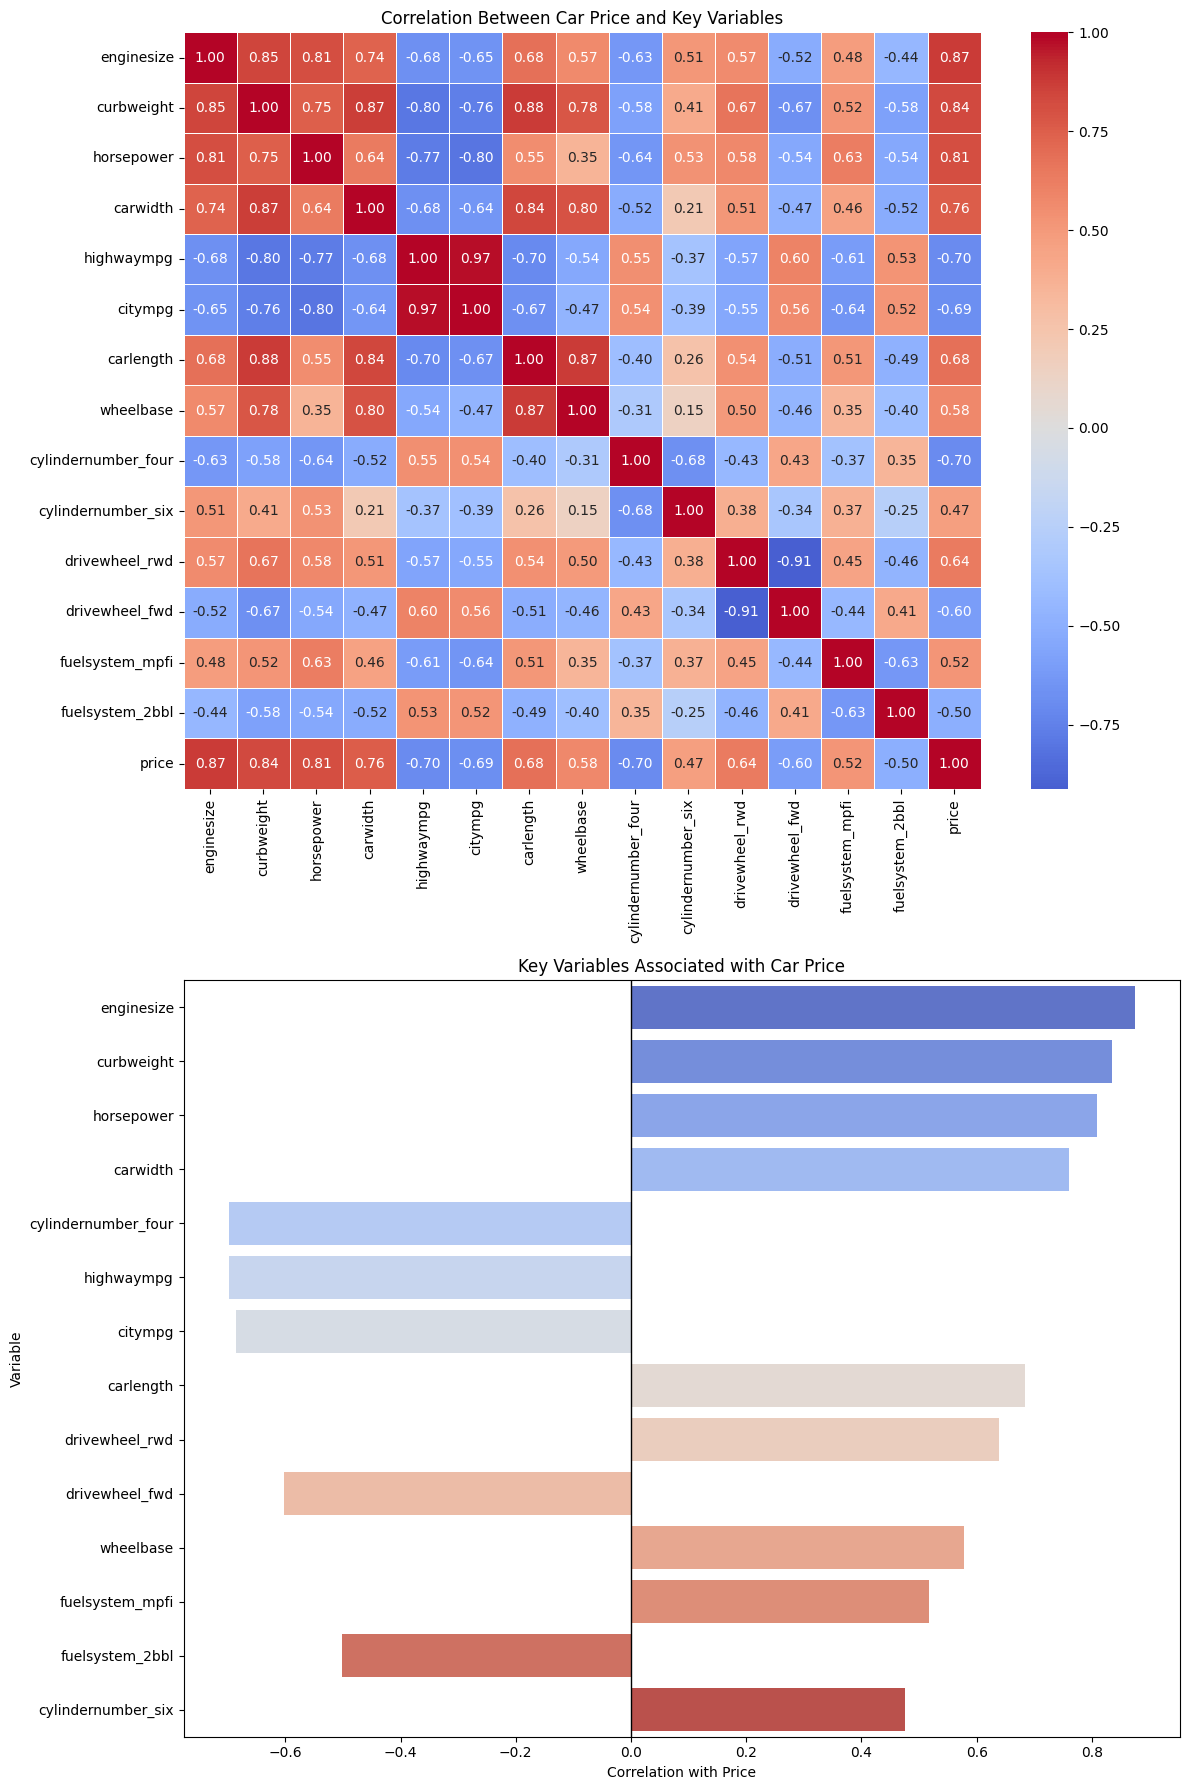

In [28]:
# Create heatmap and ranked price correlation plots
price_corr_selected = (
    selected_correlation["price"]
    .drop("price")
    .sort_values(key=abs, ascending=False)
)

fig, axes = plt.subplots(2, 1, figsize=(12, 18))

# 1. Correlation heatmap
sns.heatmap(
    selected_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0,
    ax=axes[0]
)

axes[0].set_title("Correlation Between Car Price and Key Variables")

# 2. Ranked correlations with price
sns.barplot(
    x=price_corr_selected.values,
    y=price_corr_selected.index,
    hue=price_corr_selected.index,
    palette="coolwarm",
    legend=False,
    ax=axes[1]
)

axes[1].axvline(0, color="black", linewidth=1)

axes[1].set_title("Key Variables Associated with Car Price")
axes[1].set_xlabel("Correlation with Price")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()

The correlation heatmap shows the strength and direction of relationships between the key vehicle variables and car price. Engine size has the strongest positive correlation with price (0.87), followed by curb weight (0.84), horsepower (0.81), car width (0.76) and car length (0.68). In contrast, highway MPG (-0.70) and city MPG (-0.69) have strong negative correlations with price, indicating that higher fuel economy is generally associated with lower-priced vehicles. The encoded categorical variables also show notable relationships with price, including four-cylinder vehicles (-0.70), rear-wheel drive (0.64), front-wheel drive (-0.60) and the MPFI fuel system (0.52). These relationships identify the variables that should be examined more closely in the following visualisations.

#### Detailed Correlation Analysis

The strongest relationships with car price are examined in more detail using scatter plots. This helps visualise the direction and strength of the relationships identified in the correlation analysis.

In [29]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Engine Size vs Car Price",
        "Curb Weight vs Car Price",
        "Horsepower vs Car Price",
        "Highway MPG vs Car Price"
    )
)

# Use fuel type for consistent colouring
fuel_colors = {
    "gas": "blue",
    "diesel": "red"
}

variables = [
    ("enginesize", 1, 1),
    ("curbweight", 1, 2),
    ("horsepower", 2, 1),
    ("highwaympg", 2, 2)
]

for variable, row, col in variables:

    for fuel in original_df["fueltype"].dropna().unique():

        data = original_df[original_df["fueltype"] == fuel]

        fig.add_trace(
            go.Scatter(
                x=data[variable],
                y=data["price"],
                mode="markers",
                name=fuel,
                legendgroup=fuel,
                showlegend=(row == 1 and col == 1),
                marker=dict(
                    color=fuel_colors[fuel],
                    size=7
                )
            ),
            row=row,
            col=col
        )

fig.update_xaxes(title_text="Engine Size", row=1, col=1)
fig.update_xaxes(title_text="Curb Weight", row=1, col=2)
fig.update_xaxes(title_text="Horsepower", row=2, col=1)
fig.update_xaxes(title_text="Highway MPG", row=2, col=2)

fig.update_yaxes(title_text="Car Price", row=1, col=1)
fig.update_yaxes(title_text="Car Price", row=1, col=2)
fig.update_yaxes(title_text="Car Price", row=2, col=1)
fig.update_yaxes(title_text="Car Price", row=2, col=2)

fig.update_layout(
    title="Key Numerical Variables vs Car Price",
    height=800,
    width=1100,
    template="plotly_white"
)

fig.show()

The plots show positive relationships between car price and engine size, curb weight, and horsepower, while highway MPG shows a negative relationship with price.

#### Pairwise Relationships

A pairplot is used to examine the relationships and distributions of the main numerical variables associated with car price.

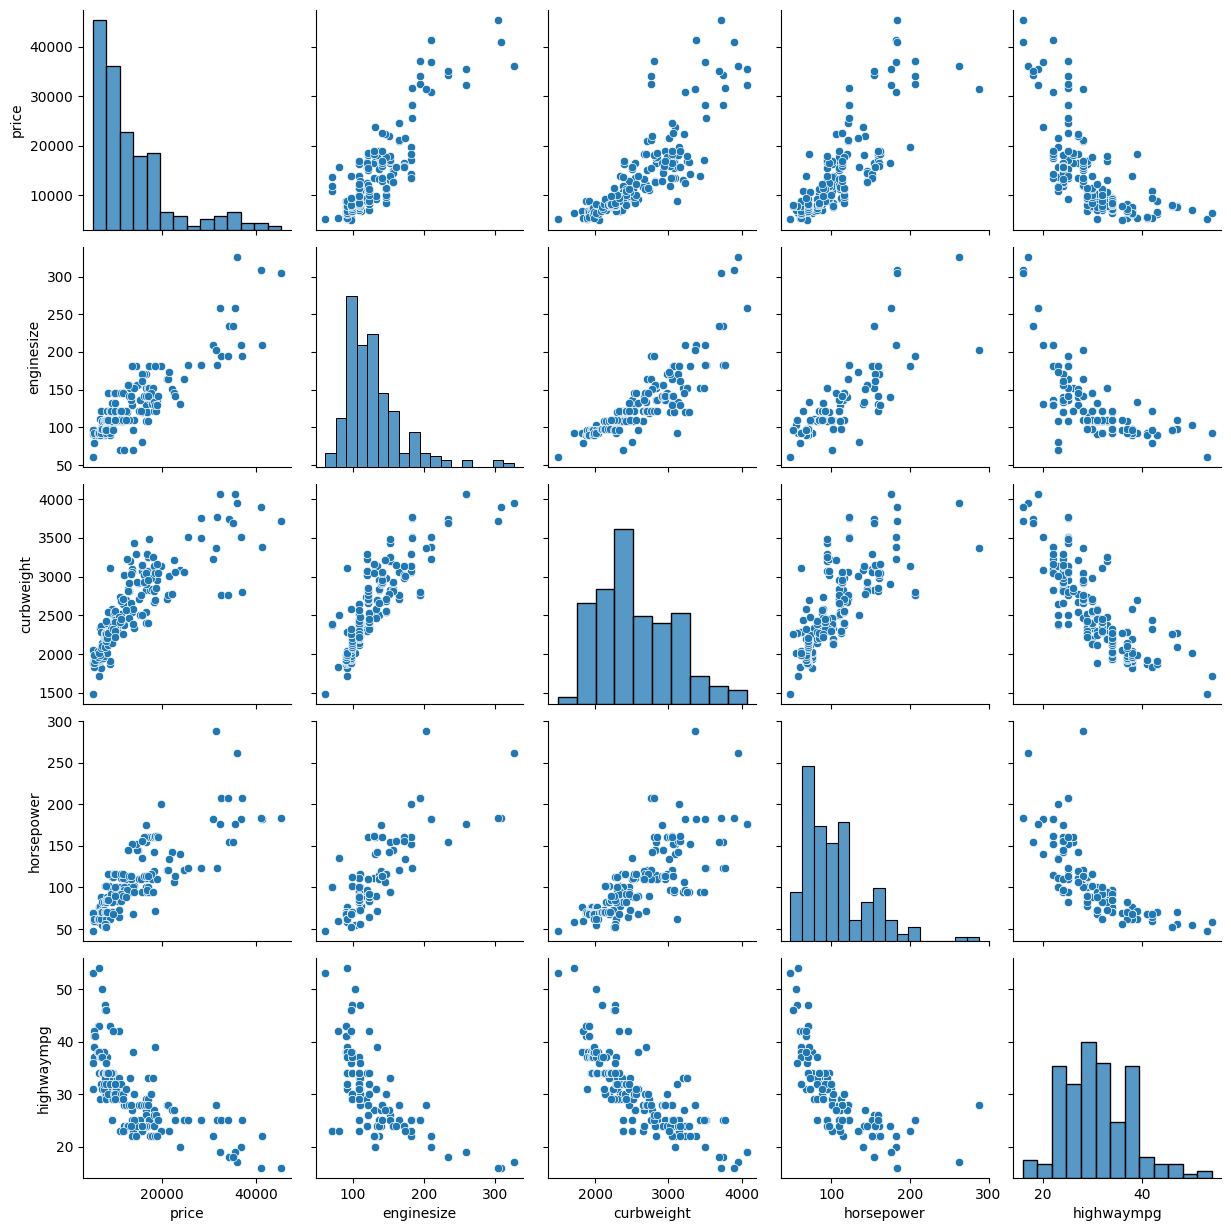

In [30]:
# Select key numerical variables
pairplot_data = original_df[
    ["price", "enginesize", "curbweight", "horsepower", "highwaympg"]
].copy()

# Create pairplot
sns.pairplot(
    pairplot_data,
    diag_kind="hist"
)

plt.show()

The pairplot confirms the strong positive relationships between price, engine size, curb weight and horsepower, while highway MPG shows a negative relationship with price.

  ### 5.3 Predictive Analysis

### Predictive Analysis: Estimating Car Prices

The predictive analysis investigates whether selected car characteristics can be used to estimate car prices. The correlation analysis was used to identify variables with relatively strong relationships with price. Based on these results, engine size, curb weight, horsepower, car width and car length were selected for further analysis.

The selected variables will first be compared between low-price and high-price vehicles to identify clear differences between the two groups. These findings will then be used to support the development of a predictive model for estimating whether a vehicle is likely to belong to the low-price or high-price group.

In [31]:
# Create price groups based on the price distribution

low_threshold = df['price'].quantile(0.20)
high_threshold = df['price'].quantile(0.80)

df['price_group'] = np.where(
    df['price'] <= low_threshold,
    'Low Price',
    np.where(
        df['price'] >= high_threshold,
        'High Price',
        'Middle Price'
    )
)

df['price_group'].value_counts()

price_group
Middle Price    123
High Price       41
Low Price        41
Name: count, dtype: int64

In [32]:
# Display the price thresholds for each group

print(f"Low-price threshold: {low_threshold:.2f}")
print(f"High-price threshold: {high_threshold:.2f}")

Low-price threshold: 7385.80
High-price threshold: 17493.80


### Strongest Positive Relationships with Price

The correlation analysis identified engine size, curb weight, horsepower and car width as the variables with the strongest positive relationships with car price. These variables were selected for further visual analysis to determine whether the differences between low-price and high-price vehicles are also clearly visible in the data.

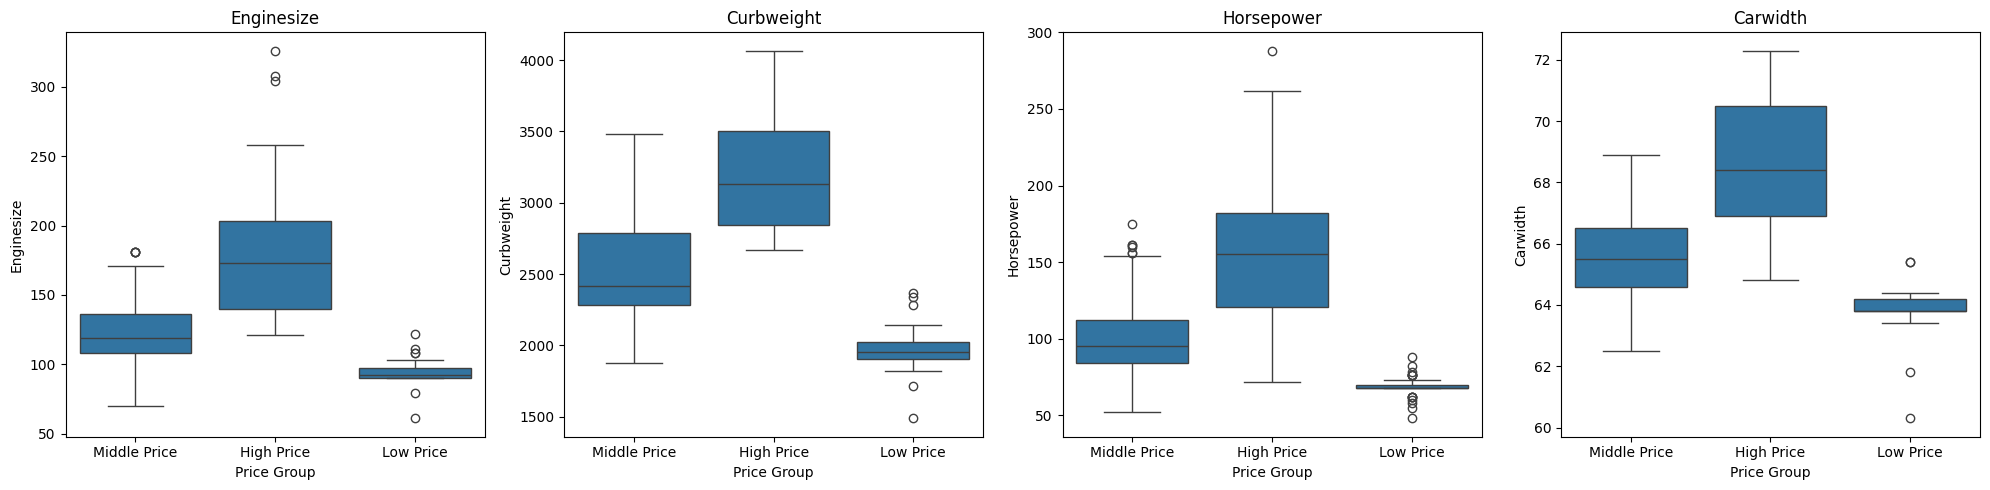

In [33]:
# Visual comparison of the strongest positive relationships

strong_features = ['enginesize', 'curbweight', 'horsepower', 'carwidth']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, feature in zip(axes, strong_features):
    sns.boxplot(
        data=df,
        x="price_group",
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Price Group')
    ax.set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

### Interpretation

The visualisations show clear differences between low-price and high-price vehicles across all four selected variables. High-price vehicles generally have larger engine sizes, greater curb weight, higher horsepower and greater car width.

These findings are consistent with the correlation analysis, where the four variables showed the strongest positive relationships with car price. Therefore, these characteristics appear to be important indicators when estimating whether a vehicle is likely to have a higher price.

### Moderate Relationships with Price

The correlation analysis identified car length, wheelbase and bore as variables with moderate positive relationships with car price. These variables were examined further to determine whether their relationships with price are also visible when comparing low-price and high-price vehicles.

In [34]:
## Recreate the price groups after adding price_group

price_groups = df[df['price_group'].isin(['Low Price', 'High Price'])].copy()

price_groups[['price_group', 'carlength', 'wheelbase', 'boreratio']].head()

,price_group,carlength,wheelbase,boreratio
6,High Price,192.7,105.8,3.19
7,High Price,192.7,105.8,3.19
8,High Price,192.7,105.8,3.13
9,High Price,178.2,99.5,3.13
12,High Price,176.8,101.2,3.31


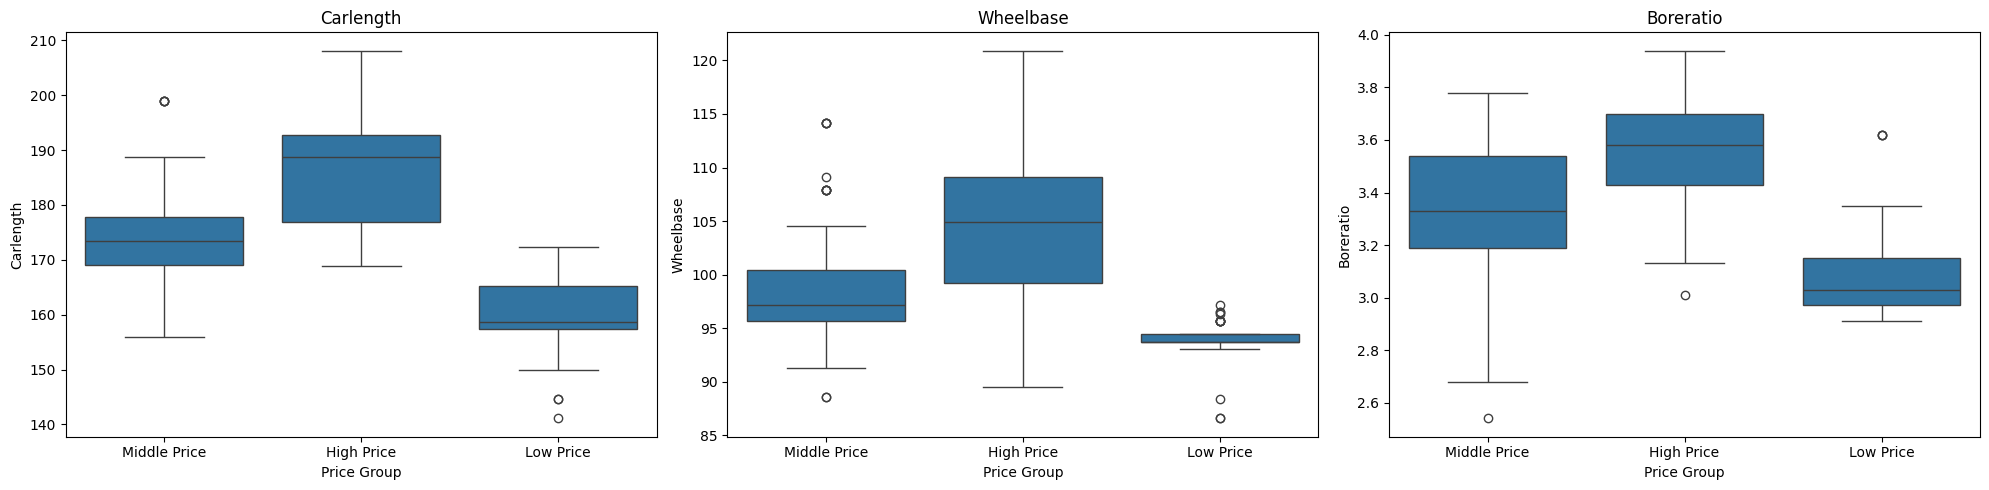

In [41]:
# Visual comparison of the strongest positive relationships

strong_features = ['carlength', 'wheelbase', 'boreratio']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, feature in zip(axes, strong_features):
    sns.boxplot(
        data=df,
        x="price_group",
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Price Group')
    ax.set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

### Interpretation

The visualisations show noticeable differences between low-price and high-price vehicles for car length, wheelbase and boreratio. High-price vehicles generally have larger values for these characteristics.

However, the differences are less pronounced than those observed for engine size, curb weight, horsepower and car width. This is consistent with their moderate positive correlations with price. These variables may therefore provide useful information for estimating car price, but they appear to be less important indicators than the strongest positively correlated variables.

### Negative Relationships with Price

The correlation analysis identified highway fuel efficiency and city fuel efficiency as variables with negative relationships with car price. These variables were selected for further visual analysis to examine how fuel efficiency differs between low-price and high-price vehicles.

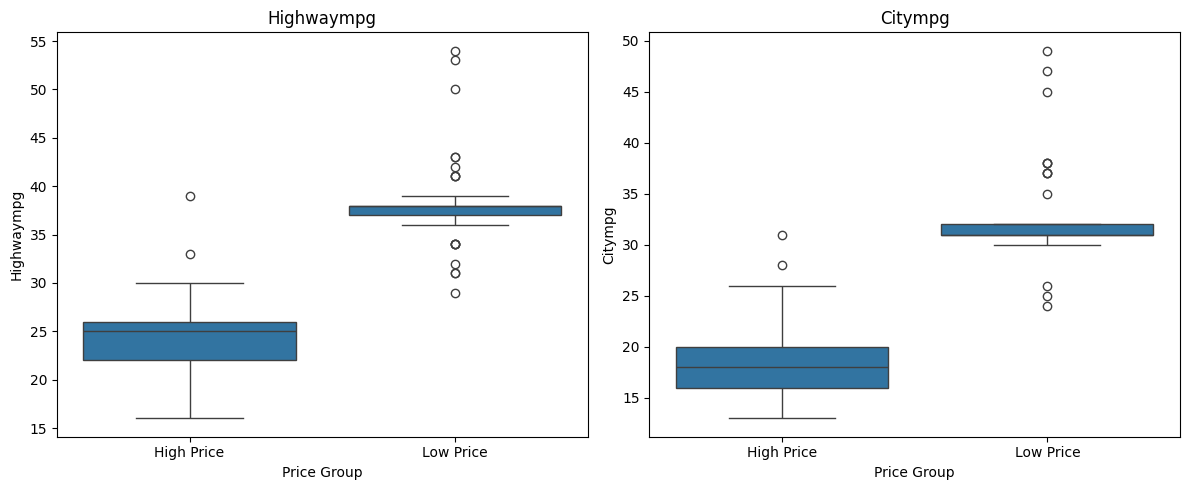

In [36]:
# Visual comparison of numerical variables with negative relationships

negative_numeric_features = ['highwaympg', 'citympg']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, negative_numeric_features):
    sns.boxplot(
        data=price_groups,
        x='price_group',
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Price Group')
    ax.set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

Highway MPG and city MPG show negative relationships with car price. The boxplots indicate that high-price vehicles generally have lower fuel efficiency than low-price vehicles.

This suggests that more expensive vehicles in this dataset tend to have larger or more powerful engines, which may result in lower fuel efficiency. However, the boxplots also show some variation and outliers within both price groups.

Therefore, highway MPG and city MPG may provide useful information for distinguishing between low-price and high-price vehicles, but their relationship with price is opposite to variables such as engine size, horsepower and curb weight.

### Negative Categorical Variables

The correlation analysis identified two encoded categorical variables with relatively strong negative relationships with car price: four-cylinder engines (`cylindernumber_four`) and front-wheel drive (`drivewheel_fwd`).

For clearer interpretation, the original categorical variables are used for visualisation. The plots compare the distribution of cylinder number and drivewheel type between low-price and high-price vehicles.

These comparisons help show whether four-cylinder engines and front-wheel drive are more common among lower-priced vehicles in this dataset.

In [37]:
# Load the original dataset
original_df = pd.read_csv('carprice_Assignment.csv')

# Check that the original categorical variable exists
print(original_df['cylindernumber'].value_counts())

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64


In [38]:
# Create price groups in the original dataset

original_df['price_group'] = np.where(
    original_df['price'] <= low_threshold,
    'Low Price',
    np.where(
        original_df['price'] >= high_threshold,
        'High Price',
        'Middle Price'
    )
)

# Keep only low- and high-price cars
cylinder_groups = original_df[
    original_df['price_group'].isin(['Low Price', 'High Price'])
].copy()

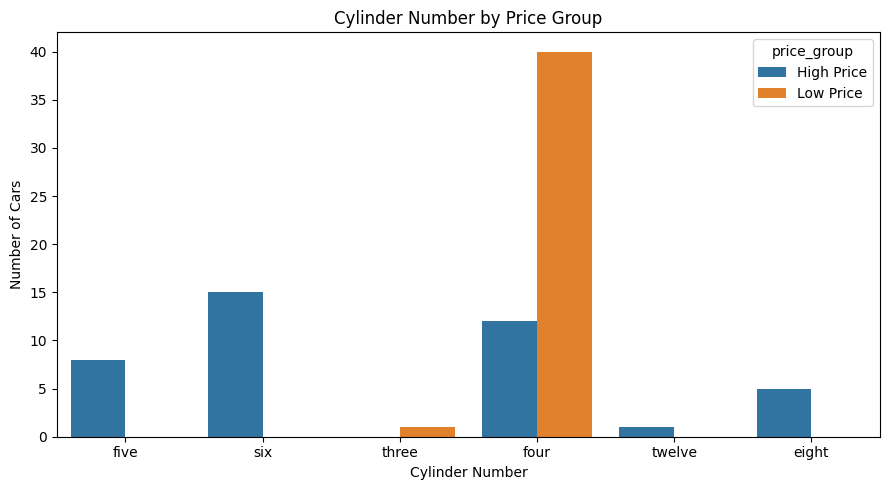

In [39]:
# Compare cylinder number between low- and high-price cars

plt.figure(figsize=(9, 5))

sns.countplot(
    data=cylinder_groups,
    x='cylindernumber',
    hue='price_group'
)

plt.title('Cylinder Number by Price Group')
plt.xlabel('Cylinder Number')
plt.ylabel('Number of Cars')

plt.tight_layout()
plt.show()

The distribution of cylinder number shows a clear difference between low-price and high-price vehicles. Four-cylinder cars are much more common in the low-price group, while five-, six-, eight- and twelve-cylinder cars are mainly found in the high-price group.

This suggests that vehicles with more cylinders tend to be associated with higher prices in this dataset. However, some cylinder categories contain very few observations, so these results should be interpreted with caution.

Overall, cylinder number appears to be a useful variable for distinguishing between low-price and high-price vehicles, and it supports the earlier correlation analysis showing a negative relationship for the four-cylinder indicator.

### Summary of Predictive Analysis

The analysis compared selected vehicle characteristics between low-price and high-price cars. The boxplots showed clear differences in engine size, horsepower, curb weight and car width between the two price groups. High-price vehicles generally had larger engines, higher horsepower, greater curb weight and greater width.

Highway MPG and city MPG showed the opposite pattern, with low-price vehicles generally having higher fuel efficiency. This is consistent with the negative correlations identified earlier.

The analysis of cylinder number also showed that higher cylinder configurations were more commonly associated with high-price vehicles, while four-cylinder vehicles were more common among low-price vehicles.

Overall, the results suggest that engine size, curb weight, horsepower, car width, fuel efficiency and cylinder number may be useful characteristics for distinguishing between low-price and high-price vehicles. However, these relationships show association rather than causation, and no predictive model is developed because predictive modelling is outside the scope of the techniques covered in this analysis.